In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_csv('Algerian_fire_cleaned_dataset.csv')

In [4]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [5]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [6]:
df['Classes'] = df['Classes'].str.strip()
df['Classes']=np.where(df['Classes']=='not fire',0,1)

In [6]:
df


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1


In [7]:
## Independent and dependent features

X=df.drop('FWI',axis=1)
y=df["FWI"]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [9]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

## Feature selection

In [10]:
def get_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    
    # Keep only upper triangle of correlation matrix
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find columns with correlation greater than threshold
    highly_correlated = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    
    return highly_correlated

In [11]:
highly_correlated_features=get_highly_correlated_features(X_train,threshold=0.85)

In [12]:
highly_correlated_features

['DC', 'BUI']

In [13]:
X_train.drop(highly_correlated_features,axis=1,inplace=True)
X_test.drop(highly_correlated_features,axis=1,inplace=True)

In [14]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

## Standardisation

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Box plot to understand the effect of standard scaler

Text(0.5, 1.0, 'X_train after scalling')

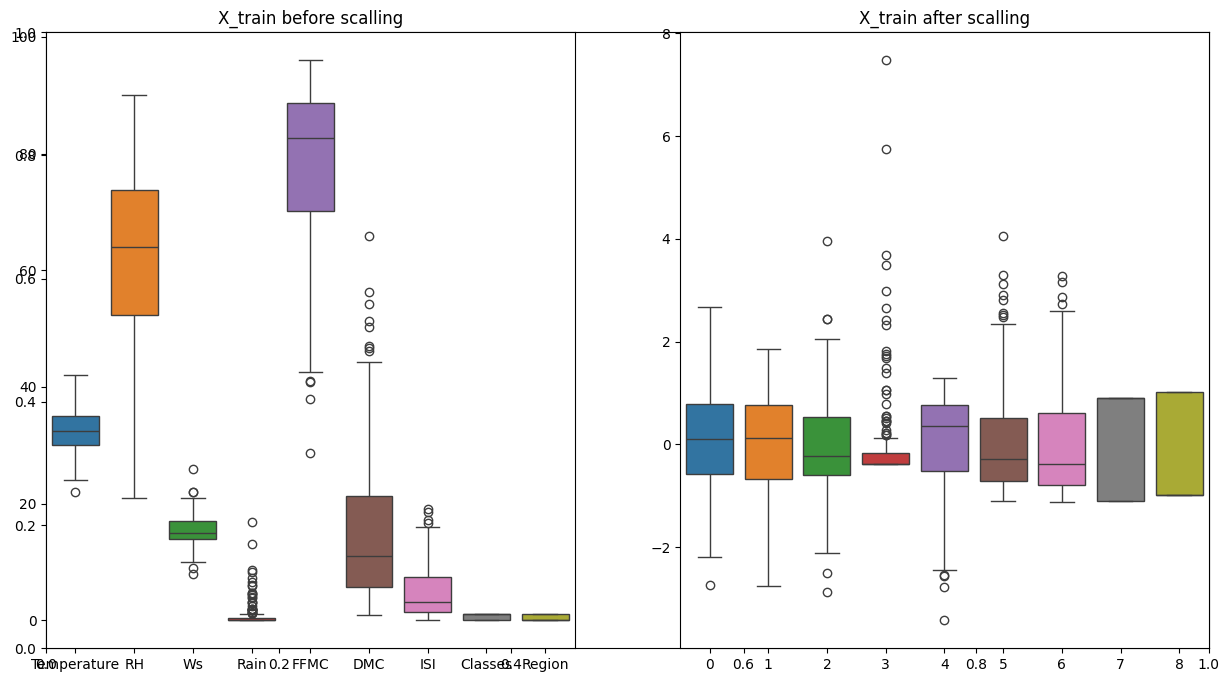

In [17]:
plt.subplots(figsize=(15,8))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scalling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after scalling')




## Linear Regression

MEA : 0.546823646524997  R2 score : 0.9847657384266951


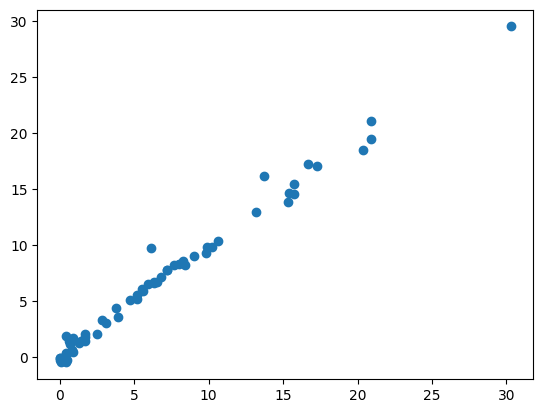

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)
y_pred=regression.predict(X_test_scaled)
mea=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MEA :",mea," R2 score :",score)
plt.scatter(y_test,y_pred)


## Lasso Regression

MAE : 1.1331759949144087  R2 score : 0.9492020263112388


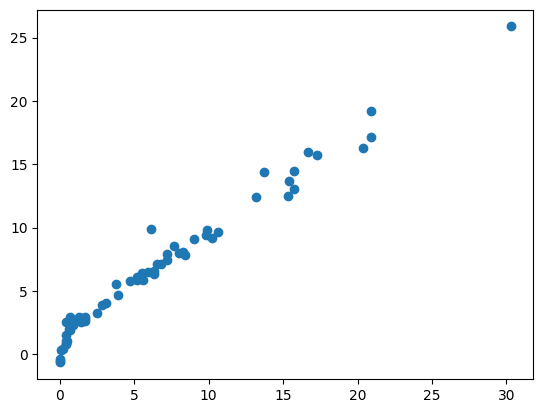

In [19]:
from sklearn.linear_model import  Lasso
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MAE :",mae," R2 score :",score)
plt.scatter(y_test,y_pred)


MAE : 0.6358894638564663  R2 score : 0.9814406737205228


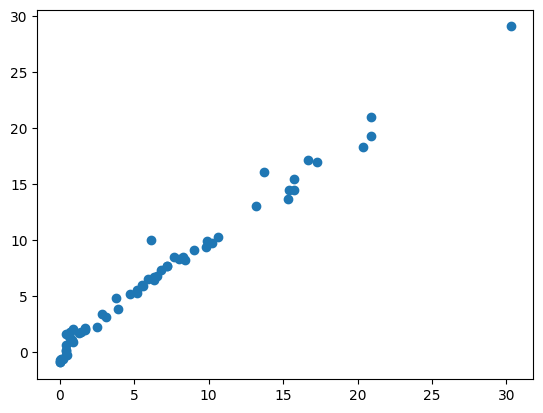

In [22]:
from sklearn.linear_model import  LassoCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
lassoCV=LassoCV(cv=5)
lassoCV.fit(X_train_scaled,y_train)
y_pred=lassoCV.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MAE :",mae," R2 score :",score)
plt.scatter(y_test,y_pred)


## Ridge Regression

MEA : 0.5642305340105691  R2 score : 0.9842993364555513


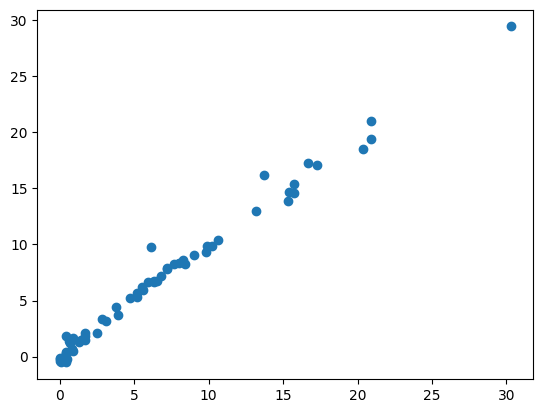

In [20]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mea=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MEA :",mea," R2 score :",score)
plt.scatter(y_test,y_pred)


MEA : 0.5642305340105691  R2 score : 0.9842993364555513


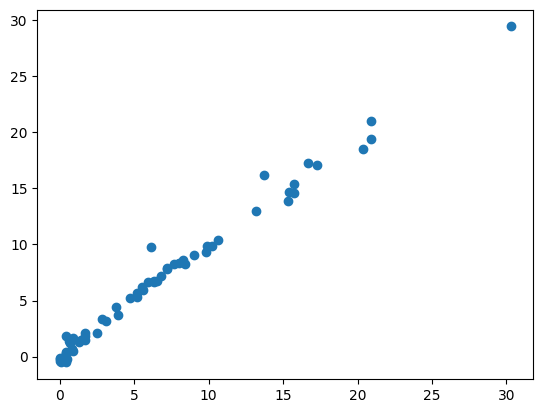

In [28]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
ridgeCV=RidgeCV(cv=5)
ridgeCV.fit(X_train_scaled,y_train)
y_pred=ridgeCV.predict(X_test_scaled)
mea=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MEA :",mea," R2 score :",score)
plt.scatter(y_test,y_pred)


## Elastic Net Regression

MEA : 1.8822353634895996  R2 score : 0.8753460589519704


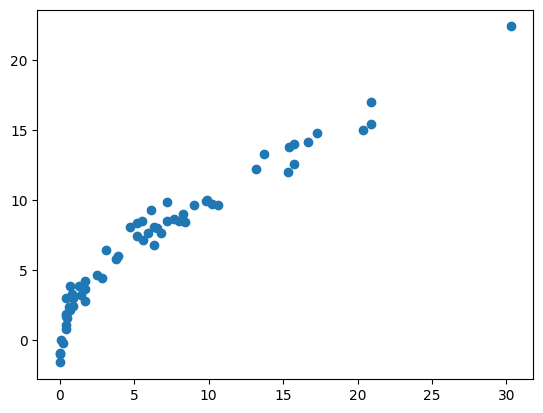

In [25]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mea=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MEA :",mea," R2 score :",score)
plt.scatter(y_test,y_pred)


MEA : 0.6575946731430902  R2 score : 0.9814217587854941


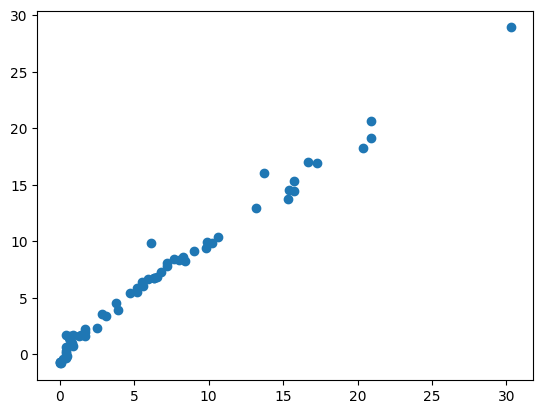

In [27]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
elasticCV=ElasticNetCV(cv=5)
elasticCV.fit(X_train_scaled,y_train)
y_pred=elasticCV.predict(X_test_scaled)
mea=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("MEA :",mea," R2 score :",score)
plt.scatter(y_test,y_pred)


In [29]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [30]:
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [31]:
import pickle
pickle.dump(scaler,open('ridge_scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))